## Plot comparison between Baseline dan DP model training

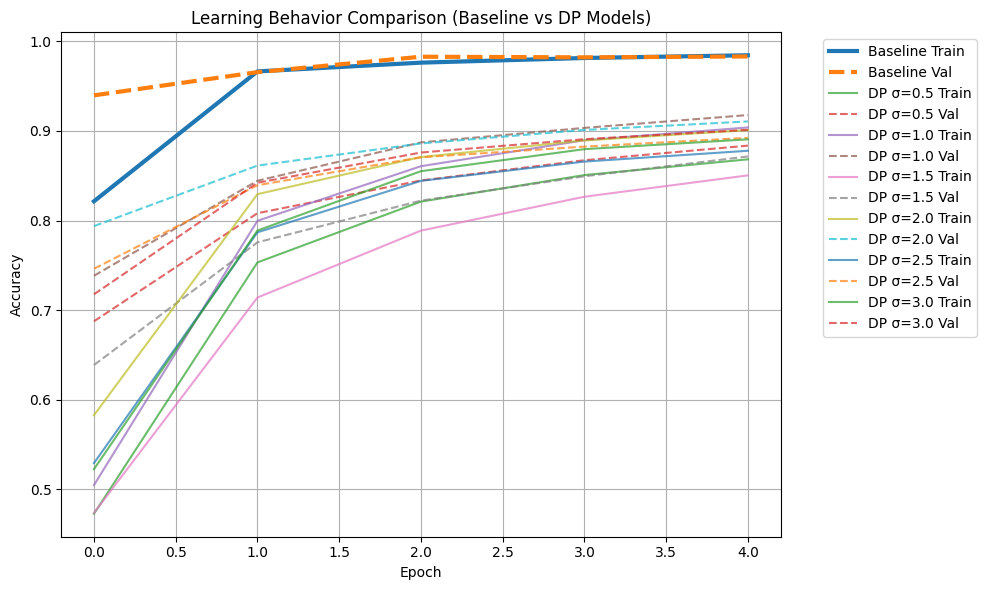

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load baseline history
baseline = pd.read_csv("results/baseline_history.csv")

# Noise levels used
noise_levels = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# Create plot
plt.figure(figsize=(10, 6))

# ----------------------------
# Plot baseline
# ----------------------------
plt.plot(baseline["accuracy"], 
         linewidth=3, 
         label="Baseline Train")

plt.plot(baseline["val_accuracy"], 
         linestyle="--", 
         linewidth=3, 
         label="Baseline Val")

# ----------------------------
# Plot all DP models
# ----------------------------
for sigma in noise_levels:
    dp = pd.read_csv(f"results/dp_history_sigma_{sigma}.csv")
    
    # Training curve
    plt.plot(dp["accuracy"], 
             label=f"DP σ={sigma} Train", 
             alpha=0.7)
    
    # Validation curve (dashed)
    plt.plot(dp["val_accuracy"], 
             linestyle="--", 
             label=f"DP σ={sigma} Val", 
             alpha=0.7)

# ----------------------------
# Labels and formatting
# ----------------------------
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Behavior Comparison (Baseline vs DP Models)")

# Move legend outside (important when many lines)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("results/learning_behavior_all.png", dpi=200)

plt.show()

## Plot Privacy Trade-Off

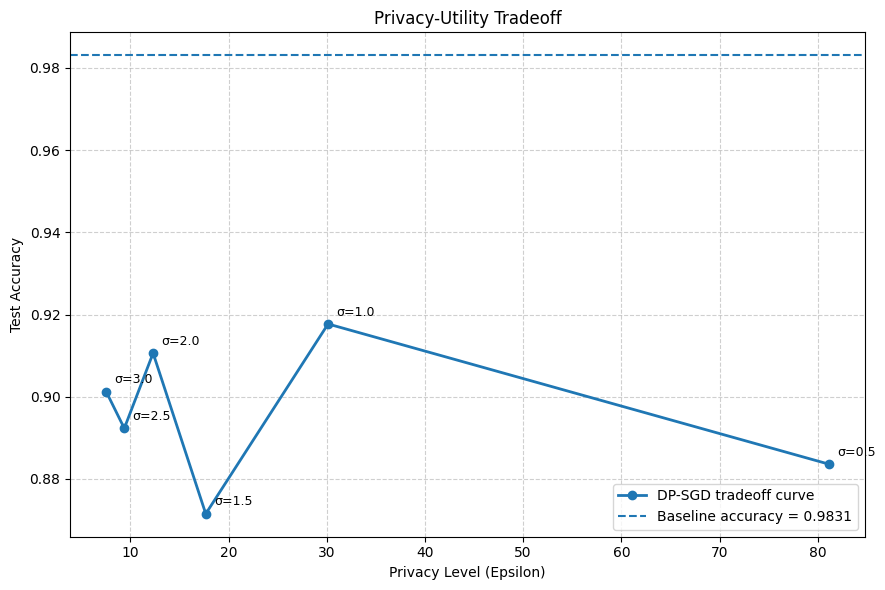

Saved plot to: results/privacy_utility_tradeoff_with_legend.png

Data used for plotting:
           model  noise_multiplier  epsilon_numeric  test_accuracy
DP-SGD_sigma_0.5               0.5           81.116         0.8836
DP-SGD_sigma_1.0               1.0           30.127         0.9177
DP-SGD_sigma_1.5               1.5           17.665         0.8715
DP-SGD_sigma_2.0               2.0           12.302         0.9106
DP-SGD_sigma_2.5               2.5            9.368         0.8923
DP-SGD_sigma_3.0               3.0            7.532         0.9012


In [6]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# Settings
# --------------------------------------------------
CSV_FILE = "results/experiment_results.csv"
OUTPUT_FILE = "results/privacy_utility_tradeoff_with_legend.png"


# --------------------------------------------------
# Helper: extract numeric epsilon from text if needed
# --------------------------------------------------
def extract_epsilon_from_text(text):
    """
    Extract epsilon value from a TensorFlow Privacy statement string.
    Looks for:
    'Epsilon with each example occurring once per epoch: 12.302'
    """
    if pd.isna(text):
        return np.nan

    text = str(text)
    match = re.search(
        r"Epsilon with each example occurring once per epoch:\s*([0-9.]+)",
        text
    )
    return float(match.group(1)) if match else np.nan


# --------------------------------------------------
# Load results
# --------------------------------------------------
df = pd.read_csv(CSV_FILE)

# Normalize column names just in case
df.columns = [c.strip() for c in df.columns]

# --------------------------------------------------
# Build numeric epsilon column robustly
# Supports:
# 1. epsilon already numeric
# 2. epsilon stored as string statement
# 3. privacy_statement column exists
# --------------------------------------------------
if "epsilon" in df.columns:
    df["epsilon_numeric"] = pd.to_numeric(df["epsilon"], errors="coerce")
else:
    df["epsilon_numeric"] = np.nan

# If epsilon column is not numeric, try privacy_statement or epsilon text itself
if df["epsilon_numeric"].isna().all():
    if "privacy_statement" in df.columns:
        df["epsilon_numeric"] = df["privacy_statement"].apply(extract_epsilon_from_text)
    elif "epsilon" in df.columns:
        df["epsilon_numeric"] = df["epsilon"].apply(extract_epsilon_from_text)

# Keep only DP rows with usable epsilon
dp_df = df[df["model"].astype(str).str.contains("DP-SGD", na=False)].copy()
dp_df = dp_df.dropna(subset=["epsilon_numeric", "test_accuracy"])

# Sort by epsilon so the line looks clean
dp_df = dp_df.sort_values("epsilon_numeric", ascending=False).reset_index(drop=True)

if len(dp_df) == 0:
    raise ValueError("No valid DP rows with numeric epsilon were found in the CSV.")

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 6))

# Main tradeoff line
plt.plot(
    dp_df["epsilon_numeric"],
    dp_df["test_accuracy"],
    marker="o",
    linewidth=2,
    label="DP-SGD tradeoff curve"
)

# Annotate each point with noise multiplier
for _, row in dp_df.iterrows():
    plt.annotate(
        f"σ={row['noise_multiplier']}",
        (row["epsilon_numeric"], row["test_accuracy"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9
    )

# Optional: add baseline as horizontal reference line
baseline_df = df[df["model"].astype(str).str.contains("Baseline", na=False)].copy()
if len(baseline_df) > 0:
    baseline_acc = float(baseline_df.iloc[0]["test_accuracy"])
    plt.axhline(
        y=baseline_acc,
        linestyle="--",
        linewidth=1.5,
        label=f"Baseline accuracy = {baseline_acc:.4f}"
    )

# Labels and title
plt.xlabel("Privacy Level (Epsilon)")
plt.ylabel("Test Accuracy")
plt.title("Privacy-Utility Tradeoff")

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Make layout clean
plt.tight_layout()

# Save and show
plt.savefig(OUTPUT_FILE, dpi=300)
plt.show()

print(f"Saved plot to: {OUTPUT_FILE}")
print("\nData used for plotting:")
print(dp_df[["model", "noise_multiplier", "epsilon_numeric", "test_accuracy"]].to_string(index=False))